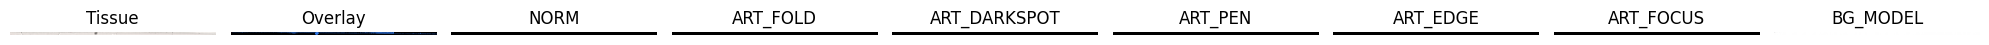

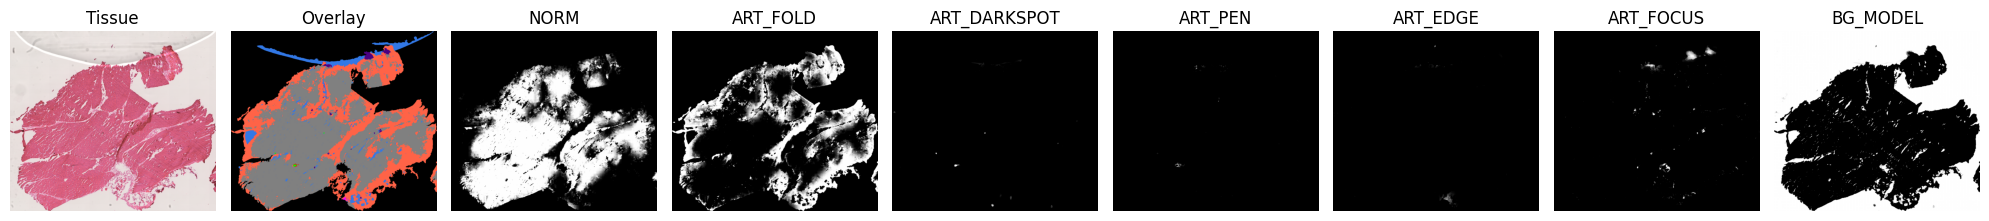

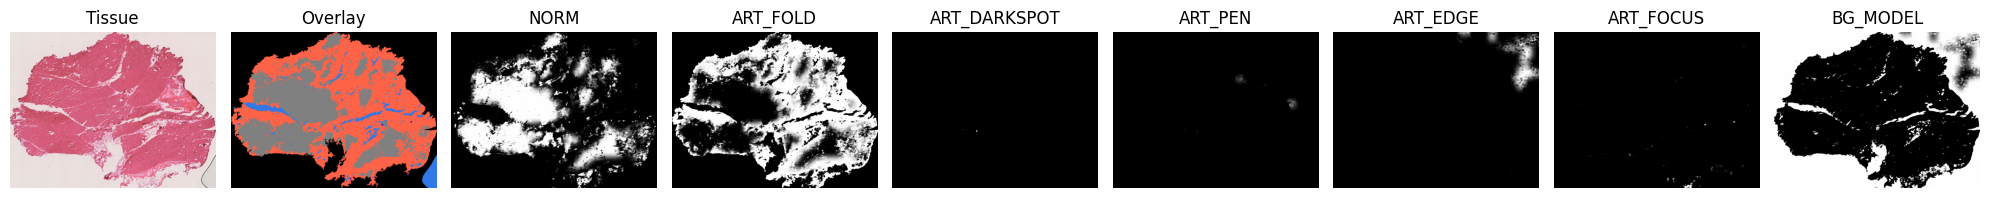

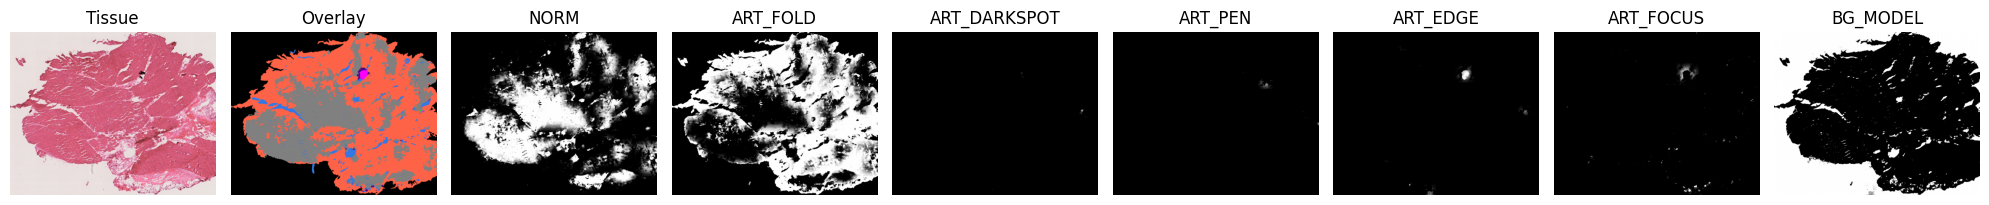

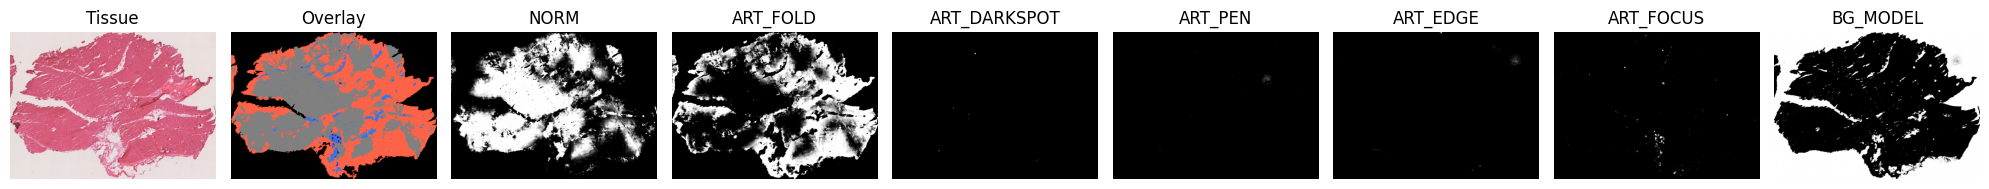

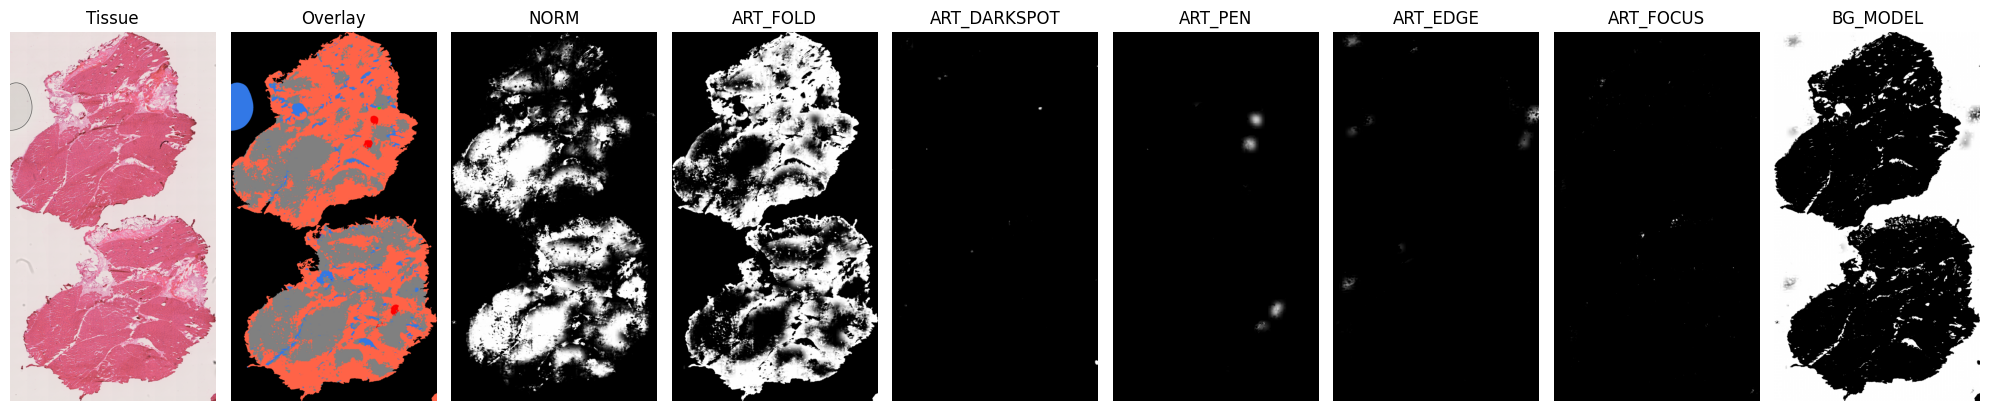

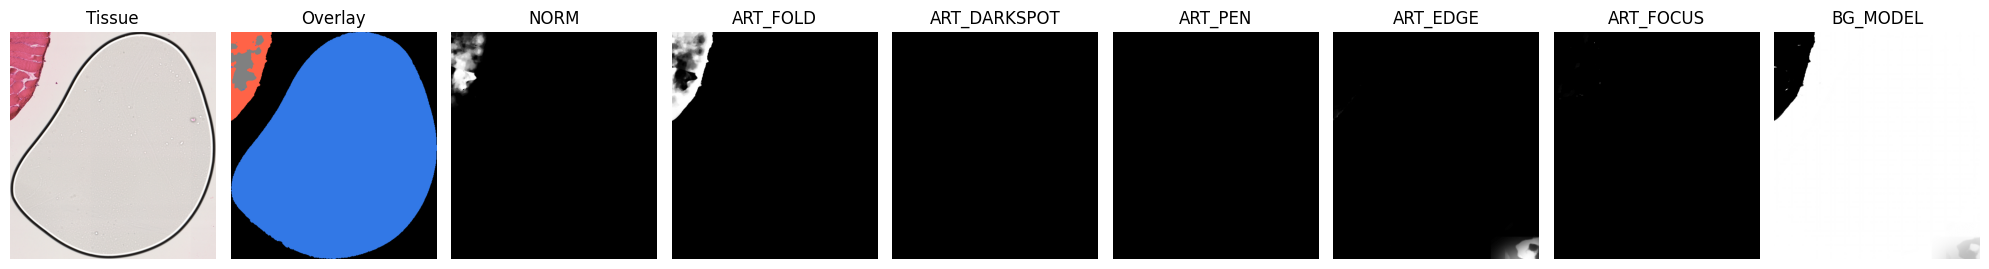

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from src.histo_kit.grand_qc.visualisation import make_artifacts_color_map
from src.histo_kit.utils.wsi import load_wsi_mag
from openslide import OpenSlide
import scipy.io as sio
from src.histo_kit.grand_qc.artifacts import Artifact

wsi_name = "28-19_he"
file = f"/mnt/data/Tmp/jmerta/Compass_HE_LMUM_20x/grandqc_confidence_maps/{wsi_name}.mat"
slide = OpenSlide(f'/mnt/data/Datasets/Compass/HE/LMUM/20x/{wsi_name}.svs')
mat = sio.loadmat(f"/mnt/data/Tmp/jmerta/Compass_HE_LMUM_20x/masks_grandqc/{wsi_name}.mat")

data = sio.loadmat(file)
region, scale_val, info, mpp_slide, ratio = load_wsi_mag(slide, 2.5, allow_upscaling=True)

for region_idx in range(mat['bbox'].shape[0]):
    raw_mask_art = data['raw_mask_art'][0][region_idx]
    bbox=mat['bbox'][region_idx]
    overlay = mat["mask_art"][0][region_idx]
    overlay = make_artifacts_color_map(overlay)
    region_0 = np.array(region)[bbox[0]:bbox[2], bbox[1]:bbox[3], :]

    plt.figure(figsize=(20, 4))

    min_val = 0
    max_val = 1

    raw_mask_art = (raw_mask_art-min_val)/(max_val-min_val)*255

    for ch in range(-1, 8):
        if ch==-1:
            img = region_0
            plt.subplot(1, 9, ch+2)
            plt.imshow(img)
            plt.axis('off')
            plt.title(f'Tissue')
        elif ch==0:
            img = overlay
            plt.subplot(1, 9, ch+2)
            plt.imshow(img)
            plt.axis('off')
            plt.title(f'Overlay')
        else:
            img = (raw_mask_art[:, :, ch]).astype(np.uint8)
            plt.subplot(1, 9, ch+2)
            plt.imshow(img, cmap='gray')
            plt.axis('off')
            plt.title(f'{Artifact(ch).name}')

    plt.tight_layout()
    plt.show()
